In [ ]:
# Clinical Question - Does systolic blood pressure increase with age in patients presenting to the emergency department?

# 2. What type of plot is appropriate (histogram, scatter, bar, box)? Scatter plot and Histogram
# A scatter plot is the most suitable choice for this bivariate question, because both Age and SBP are continuous variables.
# The scatter plot allows visual assessment of the direction, strength, and shape of the relationship.
# A histogram of SBP level among the number of patients is provided to show the  distribution of blood pressure values.

# 3. What reference lines or annotations would add clinical meaning?
#Scatter Plot:
#Hypotension threshold: SBP < 90 mmHg (horizontal blue dashed line at 90)
#Hypertension threshold: SBP ≥ 140 mmHg (horizontal orange dashed line at 140)

#Histogram:
#Hypotension: SBP < 90 mmHg
#Ideal range: 90–120 mmHg
#Pre‑hypertension: 120–139 mmHg
#Hypertensive crisis: SBP ≥ 180 mmHg




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

# MountGoogle Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/EmergencyTriageDataset_Reduced_Dirty.csv'
df = pd.read_csv(FILE_PATH)

# ── Apply all cleaning from Days 1 & 2 ───────────────────────

# Gender
gender_map = {'Male': 1, 'MALE': 1, '1': 1, 'Female': 0, 'FEMALE': 0, '0': 0}
df['Gender'] = df['Gender'].map(gender_map)

# GCS
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
df['GCS'] = df['GCS'].fillna(df['GCS'].median())

# SBP
df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
df['SBP'] = df['SBP'].fillna(df['SBP'].median())

# DBP
df['DBP'] = pd.to_numeric(df['DBP'], errors='coerce')
df.loc[(df['DBP'] < 30) | (df['DBP'] > 150), 'DBP'] = np.nan
df['DBP'] = df['DBP'].fillna(df['DBP'].median())

# Pulse
df['pulse'] = pd.to_numeric(df['pulse'], errors='coerce')
df.loc[(df['pulse'] < 20) | (df['pulse'] > 250), 'pulse'] = np.nan
df['pulse'] = df['pulse'].fillna(df['pulse'].median())

# Temp
def to_celsius(val):
    if pd.isnull(val): return np.nan
    s = str(val).strip()
    try:
        if s.endswith('C'): return float(s[:-1])
        elif s.endswith('F'): return (float(s[:-1]) - 32) * 5/9
        else: return float(s)
    except: return np.nan

df['Temp'] = df['Temp'].apply(to_celsius)
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan
df['Temp'] = df['Temp'].fillna(df['Temp'].median())

# RR
df['RR'] = pd.to_numeric(df['RR'], errors='coerce')
df.loc[(df['RR'] < 5) | (df['RR'] > 60), 'RR'] = np.nan
df['RR'] = df['RR'].fillna(df['RR'].median())

# FiO2
df['Fio2'] = pd.to_numeric(df['Fio2'], errors='coerce')
df['Fio2'] = df['Fio2'].fillna(df['Fio2'].median())  # 100% is clinically valid — no range filter

# MAP
df['MAP'] = pd.to_numeric(df['MAP'], errors='coerce')
df['MAP_Calc'] = (df['SBP'] + 2 * df['DBP']) / 3
df['MAP'] = df['MAP'].fillna(df['MAP_Calc'])
df = df.drop(columns=['MAP_Calc'])

print(f"Clean dataset: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Total NaNs remaining: {df.isnull().sum().sum()}")
df.head()

Mounted at /content/drive
Drive mounted successfully!
Clean dataset: 2205 rows x 11 columns
Total NaNs remaining: 0


,ID,Age,Gender,GCS,SBP,DBP,MAP,pulse,Temp,RR,Fio2
0,1,34,0,15.0,93.0,67.0,75.67,128.0,36.8,14.0,21.0
1,2,20,1,15.0,130.0,90.0,103.33,80.0,37.0,16.0,21.0
2,3,77,0,14.0,163.0,105.0,124.33,92.0,36.8,18.0,21.0
3,4,23,0,8.0,100.0,60.0,73.33,100.0,37.0,12.0,100.0
4,5,86,0,15.0,150.0,90.0,110.00,85.0,37.0,19.0,21.0


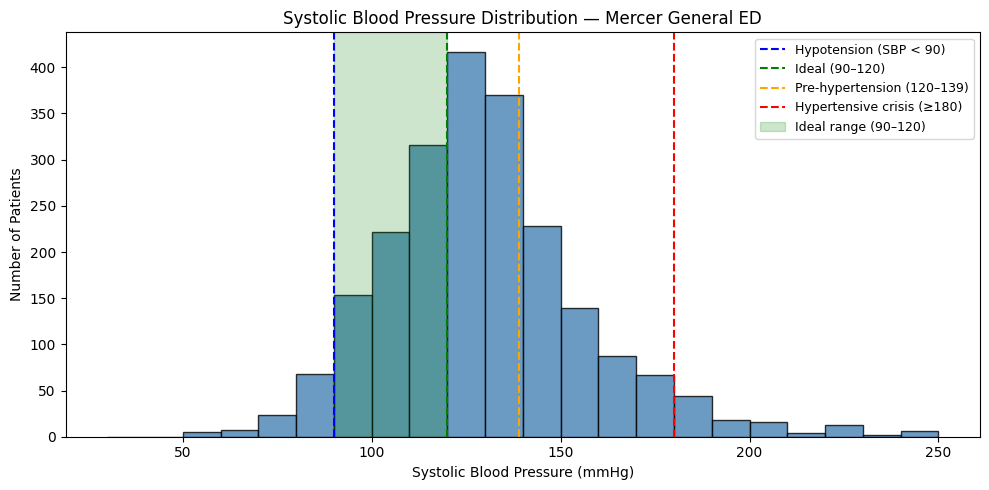

Saved: sbp_histogram.png


In [ ]:
# Histogram: SBP Distribution with Clinical Ranges
fig, ax = plt.subplots(figsize=(10, 5))

# Define bins for SBP (mmHg) – covering typical range seen in dataset
# Using 10‑mmHg bins from 30 to 250
bins = range(30, 260, 10)

ax.hist(df['SBP'].dropna(), bins=bins, edgecolor='black',
        color='steelblue', alpha=0.8)

# Clinical reference lines (based on standard hypertension guidelines)
ax.axvline(x=90, color='blue', linestyle='--', linewidth=1.5,
           label='Hypotension (SBP < 90)')
ax.axvline(x=120, color='green', linestyle='--', linewidth=1.5,
           label='Ideal (90–120)')
ax.axvline(x=139, color='orange', linestyle='--', linewidth=1.5,
           label='Pre‑hypertension (120–139)')
ax.axvline(x=180, color='red', linestyle='--', linewidth=1.5,
           label='Hypertensive crisis (≥180)')

# Shade the ideal range
ax.axvspan(90, 120, alpha=0.2, color='green', label='Ideal range (90–120)')

# Labels and title
ax.set_title('Systolic Blood Pressure Distribution — Mercer General ED', fontsize=12)
ax.set_xlabel('Systolic Blood Pressure (mmHg)')
ax.set_ylabel('Number of Patients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('sbp_histogram.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sbp_histogram.png")

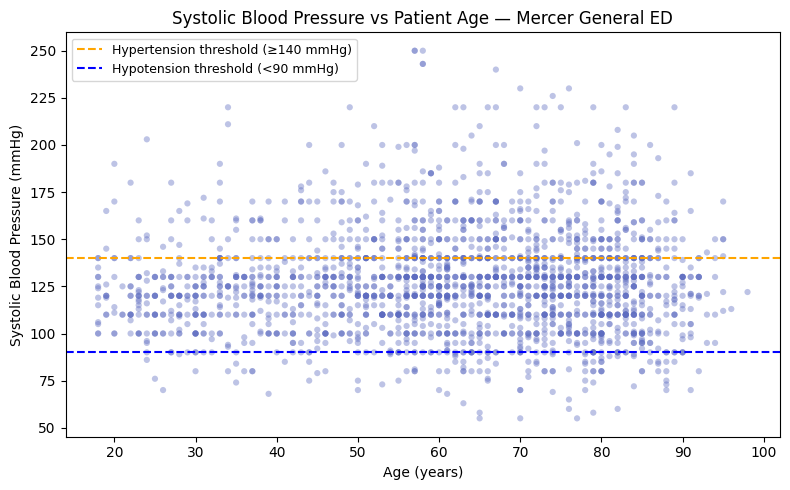

Saved: sbp_vs_age_scatter.png


In [ ]:
# Scatter plot: Age vs Systolic Blood Pressure (SBP)
fig, ax = plt.subplots(figsize=(8, 5))

# Scatter points (Age on x‑axis, SBP on y‑axis)
ax.scatter(df['Age'], df['SBP'], alpha=0.4, s=20, color='#5C6BC0', edgecolors='none')

# Reference lines for clinical thresholds
ax.axhline(y=140, color='orange', linestyle='--', linewidth=1.5,
           label='Hypertension threshold (≥140 mmHg)')
ax.axhline(y=90, color='blue', linestyle='--', linewidth=1.5,
           label='Hypotension threshold (<90 mmHg)')


# Labels, title, and legend
ax.set_title('Systolic Blood Pressure vs Patient Age — Mercer General ED', fontsize=12)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Systolic Blood Pressure (mmHg)')
ax.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig('sbp_vs_age_scatter.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved: sbp_vs_age_scatter.png")